# Load data

In [30]:
# !gdown --id '1AlnrOdJ9D1JqV8R11CUyVbKgC2rqk_RW'

In [31]:
# !unzip '/content/dataset.zip'

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from keras.utils.np_utils import to_categorical
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')


In [33]:
train_df=pd.read_csv('/content/mitbih_train.csv',header=None)
test_df=pd.read_csv('/content/mitbih_test.csv',header=None)

# Frequency for each class

In [34]:
train_df[187]=train_df[187].astype(int)
print(train_df.shape)
equilibre=train_df[187].value_counts()
print(equilibre)

(87554, 188)
0    72471
4     6431
2     5788
1     2223
3      641
Name: 187, dtype: int64


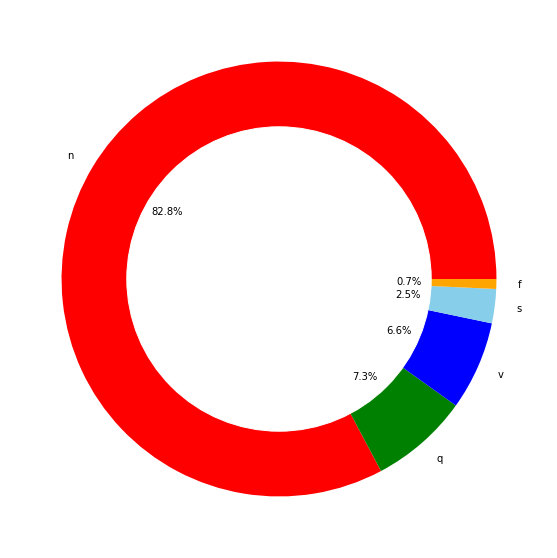

In [35]:
plt.figure(figsize=(20,10))
my_circle=plt.Circle( (0,0), 0.7, color='white')
plt.pie(equilibre, labels=['n','q','v','s','f'], colors=['red','green','blue','skyblue','orange'],autopct='%1.1f%%')
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

# Resampling

In [36]:
from sklearn.utils import resample
df_1=train_df[train_df[187]==1]
df_2=train_df[train_df[187]==2]
df_3=train_df[train_df[187]==3]
df_4=train_df[train_df[187]==4]
df_0=(train_df[train_df[187]==0]).sample(n=20000,random_state=42)

df_1_upsample=resample(df_1,replace=True,n_samples=20000,random_state=123)
df_2_upsample=resample(df_2,replace=True,n_samples=20000,random_state=124)
df_3_upsample=resample(df_3,replace=True,n_samples=20000,random_state=125)
df_4_upsample=resample(df_4,replace=True,n_samples=20000,random_state=126)

train_df=pd.concat([df_0,df_1_upsample,df_2_upsample,df_3_upsample,df_4_upsample])

In [37]:
equilibre=train_df[187].value_counts()
print(equilibre)


4    20000
3    20000
2    20000
1    20000
0    20000
Name: 187, dtype: int64


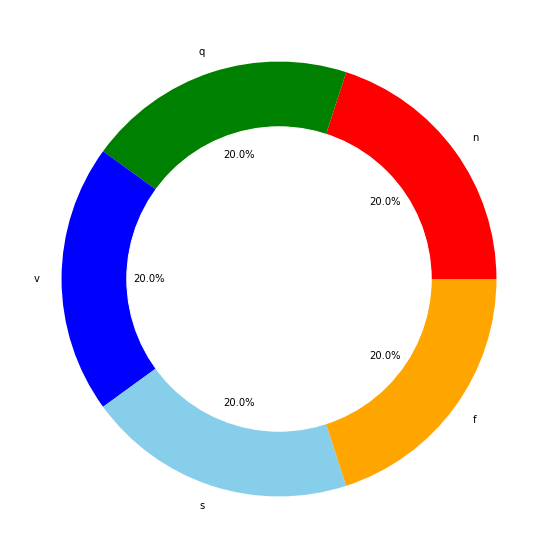

In [38]:
plt.figure(figsize=(20,10))
my_circle=plt.Circle( (0,0), 0.7, color='white')
plt.pie(equilibre, labels=['n','q','v','s','f'], colors=['red','green','blue','skyblue','orange'],autopct='%1.1f%%')
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

# One sample from per class

In [39]:
c=train_df.groupby(187,group_keys=False).apply(lambda train_df : train_df.sample(1))
c

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187
41932,0.941718,0.883436,0.469325,0.226994,0.180982,0.174847,0.119632,0.107362,0.088957,0.085890,0.064417,0.070552,0.055215,0.055215,0.046012,0.052147,0.036810,0.049080,0.033742,0.036810,0.015337,0.000000,0.003067,0.012270,0.018405,0.061350,0.082822,0.122699,0.116564,0.141104,0.150307,0.168712,0.144172,0.156442,0.138037,0.150307,0.141104,0.150307,0.128834,0.147239,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
73421,0.863436,0.920705,0.273128,0.000000,0.079295,0.145374,0.118943,0.180617,0.242291,0.224670,0.237885,0.295154,0.330396,0.409692,0.427313,0.334802,0.409692,0.431718,0.392070,0.370044,0.396476,0.422908,0.409692,0.378855,0.418502,0.436123,0.497797,0.488987,0.502203,0.599119,0.581498,0.572687,0.634361,0.638767,0.629956,0.599119,0.607930,0.559471,0.519824,0.444934,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
77969,0.996491,0.887719,0.736842,0.449123,0.189474,0.070175,0.056140,0.056140,0.080702,0.049123,0.070175,0.049123,0.056140,0.056140,0.077193,0.049123,0.049123,0.035088,0.042105,0.021053,0.024561,0.003509,0.021053,0.000000,0.014035,0.014035,0.049123,0.070175,0.108772,0.122807,0.164912,0.189474,0.221053,0.217544,0.242105,0.231579,0.238596,0.221053,0.224561,0.196491,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
80849,1.000000,0.967436,0.792402,0.503392,0.238806,0.138399,0.157395,0.120760,0.100407,0.101764,0.093623,0.074627,0.061058,0.051560,0.048847,0.040706,0.040706,0.044776,0.048847,0.046133,0.059701,0.080054,0.105834,0.123474,0.146540,0.191316,0.225237,0.253731,0.291723,0.316147,0.340570,0.339213,0.341927,0.351425,0.331072,0.309362,0.297151,0.286296,0.271370,0.245590,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
85583,0.925602,0.877462,0.824945,0.777899,0.716630,0.649891,0.565646,0.480306,0.412473,0.332604,0.303063,0.294311,0.245077,0.172867,0.135667,0.192560,0.276805,0.304158,0.326039,0.333698,0.331510,0.339168,0.365427,0.389497,0.426696,0.456236,0.501094,0.528446,0.539387,0.555799,0.557987,0.567834,0.577681,0.587527,0.607221,0.612691,0.635667,0.660832,0.680525,0.703501,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


# ECG Signal Plot

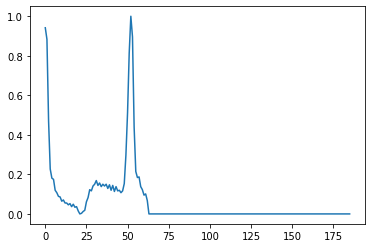

In [40]:
 plt.plot(c.iloc[0,:186])

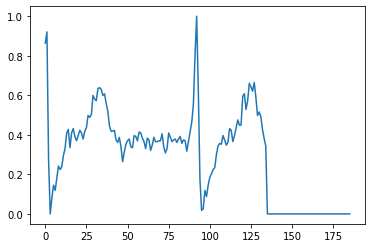

In [41]:
 plt.plot(c.iloc[1,:186])

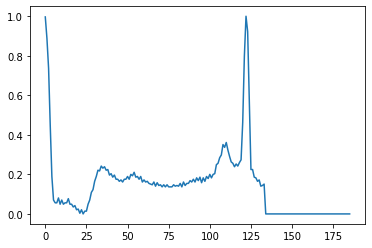

In [42]:
 plt.plot(c.iloc[2,:186])

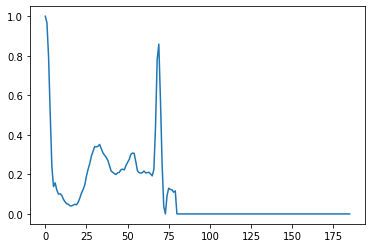

In [43]:
plt.plot(c.iloc[3,:186])

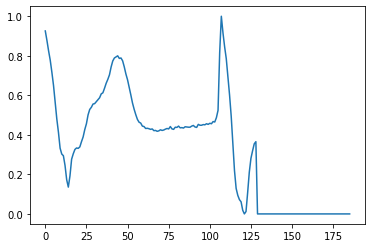

In [44]:
plt.plot(c.iloc[4,:186])

# Transform data

In [45]:
target_train=train_df[187]
target_test=test_df[187]
y_train=to_categorical(target_train)
y_test=to_categorical(target_test)

In [46]:
X_train=train_df.iloc[:,:186].values
X_test=test_df.iloc[:,:186].values

# Model

In [47]:
def network(X_train,y_train,X_test,y_test):
    

    im_shape=(X_train.shape[1],1)
    inputs_cnn=Input(shape=(im_shape), name='inputs_cnn')
    
    conv1_1=Convolution1D(64, (6), activation='relu', input_shape=im_shape)(inputs_cnn)
    conv1_1=BatchNormalization()(conv1_1)
    pool1=MaxPool1D(pool_size=(3), strides=(2), padding="same")(conv1_1)

    conv2_1=Convolution1D(64, (3), activation='relu', input_shape=im_shape)(pool1)
    conv2_1=BatchNormalization()(conv2_1)
    pool2=MaxPool1D(pool_size=(2), strides=(2), padding="same")(conv2_1)

    conv3_1=Convolution1D(64, (3), activation='relu', input_shape=im_shape)(pool2)
    conv3_1=BatchNormalization()(conv3_1)
    pool3=MaxPool1D(pool_size=(2), strides=(2), padding="same")(conv3_1)

    flatten=Flatten()(pool3)
    dense_end1 = Dense(64, activation='relu')(flatten)
    dense_end2 = Dense(32, activation='relu')(dense_end1)
    main_output = Dense(5, activation='softmax', name='main_output')(dense_end2)
    
    model = Model(inputs= inputs_cnn, outputs=main_output)
    model.compile(optimizer='adam', loss='categorical_crossentropy',metrics = ['accuracy'])
    
    callbacks = [ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True)]

    history=model.fit(X_train, y_train,epochs=50,callbacks=callbacks, batch_size=32,validation_data=(X_test,y_test))
    model.load_weights('best_model.h5')
    return(model,history, model.summary())


In [48]:
def evaluate_model(history,X_test,y_test,model):
    scores = model.evaluate((X_test),y_test, verbose=0)
    print("Accuracy: %.2f%%" % (scores[1]*100))
    
    print(history)
    fig1, ax_acc = plt.subplots()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Model - Accuracy')
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()
    
    fig2, ax_loss = plt.subplots()
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Model- Loss')
    plt.legend(['Training', 'Validation'], loc='upper right')
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.show()
    target_names=['0','1','2','3','4']
    
    y_true=[]
    for element in y_test:
        y_true.append(np.argmax(element))
    prediction_proba=model.predict(X_test)
    prediction=np.argmax(prediction_proba,axis=1)
    cnf_matrix = confusion_matrix(y_true, prediction)
    

In [49]:
X_train.shape

(100000, 186)

In [50]:
from keras.layers import Dense, Convolution1D, MaxPool1D, Flatten, Dropout
from keras.layers import Input
from keras.models import Model
from keras.layers import BatchNormalization
import keras
from keras.callbacks import EarlyStopping, ModelCheckpoint
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train, test_size = .10)
model,history,summary=network(X_train,y_train,X_val,y_val)
summary

Epoch 1/50
2813/2813 [==============================] - 30s 10ms/step - loss: 0.2006 - accuracy: 0.9287 - val_loss: 0.1314 - val_accuracy: 0.9478
Epoch 2/50
2813/2813 [==============================] - 28s 10ms/step - loss: 0.0787 - accuracy: 0.9732 - val_loss: 0.0647 - val_accuracy: 0.9782
Epoch 3/50
2813/2813 [==============================] - 29s 10ms/step - loss: 0.0516 - accuracy: 0.9822 - val_loss: 0.0485 - val_accuracy: 0.9835
Epoch 4/50
2813/2813 [==============================] - 28s 10ms/step - loss: 0.0402 - accuracy: 0.9865 - val_loss: 0.0414 - val_accuracy: 0.9876
Epoch 5/50
2813/2813 [==============================] - 28s 10ms/step - loss: 0.0316 - accuracy: 0.9900 - val_loss: 0.0933 - val_accuracy: 0.9716
Epoch 6/50
2813/2813 [==============================] - 28s 10ms/step - loss: 0.0255 - accuracy: 0.9916 - val_loss: 0.0572 - val_accuracy: 0.9851
Epoch 7/50
2813/2813 [==============================] - 28s 10ms/step - loss: 0.0219 - accuracy: 0.9929 - val_loss: 0.0578 -

# Evaluation

Accuracy: 98.02%


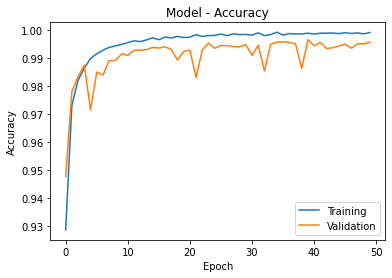

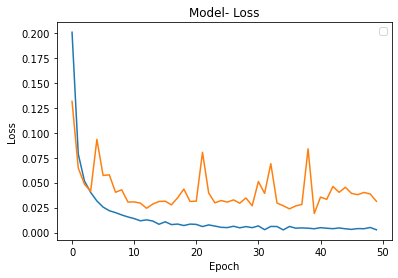

In [51]:
evaluate_model(history,X_test,y_test,model)
y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred, axis=1)
y_test=np.argmax(y_test, axis=1)

In [52]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report

In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.77      0.85      0.81       556
           2       0.95      0.96      0.95      1448
           3       0.74      0.79      0.76       162
           4       0.98      0.99      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.88      0.92      0.90     21892
weighted avg       0.98      0.98      0.98     21892



Normalized confusion matrix


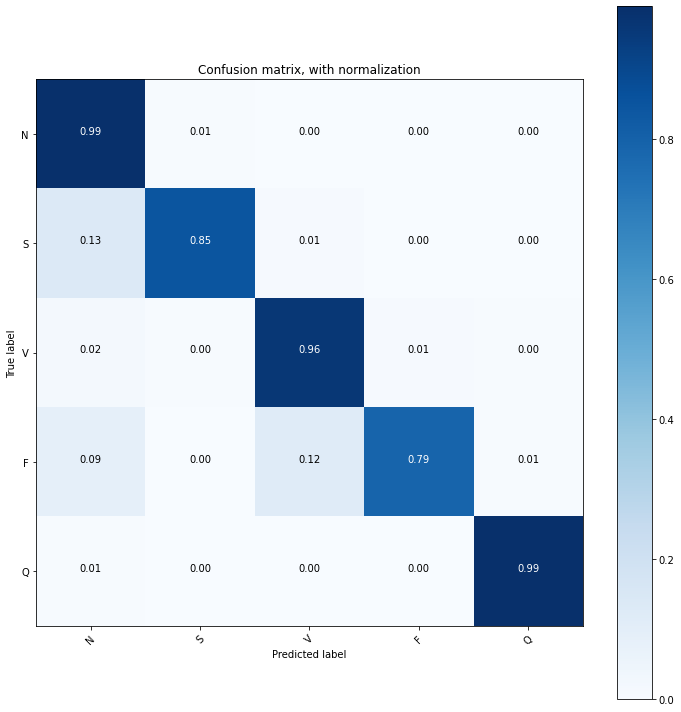

In [54]:
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix, classes=['N', 'S', 'V', 'F', 'Q'],normalize=True,
                      title='Confusion matrix, with normalization')
plt.show()

